<a href="https://colab.research.google.com/github/Arooba10467/AI-Artificial-Intelligence-CSC4101/blob/main/Assighment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Arooba (2312145)

# Home Task
● Generate valid dataset for Logistic Regression with 5 Features
●

● 100 Training Samples, 10 Testing samples

In [ ]:
import numpy as np
import pandas as pd

np.random.seed(42)

# 5 features
X_train = np.random.randn(100, 5)
X_test = np.random.randn(10, 5)

# True weights (hidden logic)
true_w = np.array([1.2, -1.5, 2.0, -0.8, 1.0])
b_true = 0.5

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Generate labels
y_train = (sigmoid(np.dot(X_train, true_w) + b_true) > 0.5).astype(int)
y_test = (sigmoid(np.dot(X_test, true_w) + b_true) > 0.5).astype(int)

# Save CSV
train_df = pd.DataFrame(X_train, columns=[f'f{i}' for i in range(5)])
train_df['label'] = y_train
train_df.to_csv("train_data.csv", index=False)

test_df = pd.DataFrame(X_test, columns=[f'f{i}' for i in range(5)])
test_df['label'] = y_test
test_df.to_csv("test_data.csv", index=False)

print("CSV files generated")

CSV files generated


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

train = pd.read_csv("train_data.csv")
test = pd.read_csv("test_data.csv")

X = train.iloc[:, :-1].values
y = train.iloc[:, -1].values

X_test = test.iloc[:, :-1].values
y_test = test.iloc[:, -1].values

In [ ]:
y.shape

(100,)

# Assighment part

Design a Logistic Regression using Python

● Print model weights before training

In [ ]:
# Initialize weights
w = np.zeros(X.shape[1])
b = 0.0

print("Initial Weights:", w)
print("Initial Bias:", b)

# Hyperparameters
lr = 0.1
Epochs = 10   # IMPORTANT (as required)

n = len(X)
losses = []

Initial Weights: [0. 0. 0. 0. 0.]
Initial Bias: 0.0


● Train the model on Generated training data for 10 epochs

In [ ]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

for e in range(Epochs):

    # Forward pass
    z = np.dot(X, w) + b
    y_p = sigmoid(z)

    # Loss (Binary Cross Entropy)
    loss = -np.mean(y * np.log(y_p + 1e-9) + (1 - y) * np.log(1 - y_p + 1e-9))
    losses.append(loss)

    # Gradients
    dw = (1/n) * np.dot(X.T, (y_p - y))
    db = (1/n) * np.sum(y_p - y)

    # Update weights
    w = w - lr * dw
    b = b - lr * db

    print(f"Epoch {e+1}, Loss: {loss:.4f}")

Epoch 1, Loss: 0.6931
Epoch 2, Loss: 0.6791
Epoch 3, Loss: 0.6658
Epoch 4, Loss: 0.6532
Epoch 5, Loss: 0.6411
Epoch 6, Loss: 0.6296
Epoch 7, Loss: 0.6186
Epoch 8, Loss: 0.6082
Epoch 9, Loss: 0.5982
Epoch 10, Loss: 0.5887


● Print Training loss using seaborn or matplotlib

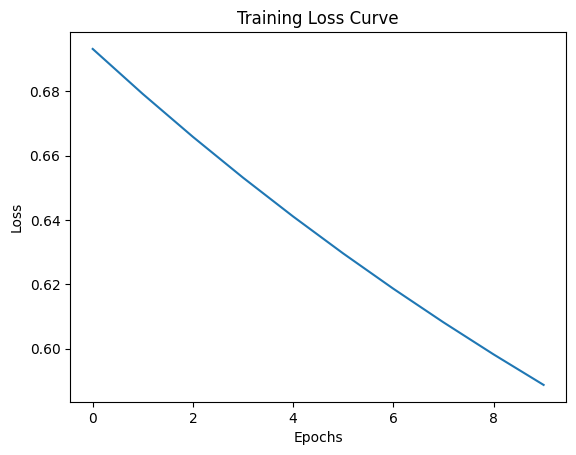

In [ ]:
plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()

● Print new weights

In [ ]:
print("Updated Weights:", w)
print("Updated Bias:", b)

Updated Weights: [ 0.1457231  -0.17240897  0.20801929 -0.10230117  0.09787579]
Updated Bias: -0.0028580357137780463


● Make predictions on testing dataset

In [ ]:
z_test = np.dot(X_test, w) + b
y_prob = sigmoid(z_test)

# Convert to 0/1
y_pred = (y_prob > 0.5).astype(int)

print("Predictions:", y_pred)
print("Actual:", y_test)

Predictions: [0 0 1 0 0 0 1 0 1 0]
Actual: [0 0 1 0 0 0 1 0 1 0]


● Evaluate results using Evaluation metric (what evaluation metric we use for logistic
regression)

In [ ]:
accuracy = np.mean(y_pred == y_test)
print("Accuracy:", accuracy)

Accuracy: 1.0
